In [30]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use("seaborn-v0_8-talk")

In [31]:
data = pd.read_csv('listings.csv')
data

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3176,https://www.airbnb.com/rooms/3176,20250923202926,2025-09-24,city scrape,Fabulous Flat in great Location,This beautiful first floor apartment is situa...,The neighbourhood is famous for its variety of...,https://a0.muscache.com/pictures/hosting/Hosti...,3718,...,4.70,4.92,4.61,First name and Last name: Nicolas Krotz <br/> ...,f,1,1,0,0,0.76
1,9991,https://www.airbnb.com/rooms/9991,20250923202926,2025-09-24,city scrape,Geourgeous flat - outstanding views,4 bedroom with very large windows and outstand...,Prenzlauer Berg is an amazing neighbourhood wh...,https://a0.muscache.com/pictures/42799131/59c8...,33852,...,5.00,4.86,4.86,03/Z/RA/003410-18,f,1,1,0,0,0.06
2,14325,https://www.airbnb.com/rooms/14325,20250923202926,2025-09-24,city scrape,Studio Apartment in Prenzlauer Berg,The apartment is located on the upper second f...,NaN,https://a0.muscache.com/pictures/508703/24988a...,55531,...,4.85,4.60,4.45,NaN,f,4,4,0,0,0.14
3,17904,https://www.airbnb.com/rooms/17904,20250923202926,2025-09-24,city scrape,Beautiful Kreuzberg studio - 3 months minimum,"- apt is available starting October 1, 2025 (m...","The apartment is located in Kreuzberg, which i...",https://a0.muscache.com/pictures/d9a6f8be-54b9...,68997,...,4.92,4.88,4.65,NaN,f,1,1,0,0,1.57
4,20858,https://www.airbnb.com/rooms/20858,20250923202926,2025-09-24,city scrape,Designer Loft in Berlin Mitte,Bright and sunny condo with two balconies in a...,Fantastic vibe in the middle of the popular Ka...,https://a0.muscache.com/pictures/108232/205b19...,71331,...,4.54,4.91,4.39,03/Z/RA/009767-24,f,1,1,0,0,0.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14269,1515762441083891582,https://www.airbnb.com/rooms/1515762441083891582,20250923202926,2025-09-24,city scrape,Cozy 2-Bedroom Apartment in Pankow,This stunning furnished two bedroom apartment ...,Pankow offers a peaceful retreat while still b...,https://a0.muscache.com/pictures/prohost-api/H...,595670462,...,NaN,NaN,NaN,NaN,f,107,107,0,0,NaN
14270,1515762449478095365,https://www.airbnb.com/rooms/1515762449478095365,20250923202926,2025-09-24,city scrape,Beautiful 1-Bedroom Apartment in Neukölln,This stunning furnished one bedroom apartment ...,"Welcome to Neukölln, a vibrant mosaic of cultu...",https://a0.muscache.com/pictures/prohost-api/H...,595670462,...,NaN,NaN,NaN,NaN,f,107,107,0,0,NaN
14271,1515796546337797524,https://www.airbnb.com/rooms/1515796546337797524,20250923202926,2025-09-24,city scrape,Tasteful Studio in Kreuzberg,This stunning furnished studio apartment featu...,Kreuzberg is one of Berlin’s most dynamic and ...,https://a0.muscache.com/pictures/prohost-api/H...,595670462,...,NaN,NaN,NaN,NaN,f,107,107,0,0,NaN
14272,1515901877338207449,https://www.airbnb.com/rooms/1515901877338207449,20250923202926,2025-09-24,city scrape,Large bright room with balcony in historic Rix...,This unique place has a style all its own.,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,21803389,...,NaN,NaN,NaN,08/Z/AZ/213486-24,f,2,1,1,0,NaN


# 1. Datenbereinigung

## 1.1 Vorauswahl relevanter Attribute

In [32]:
cols = ['id','listing_url','amenities','price','neighbourhood_group_cleansed','property_type','room_type','accommodates','bathrooms',
        'bedrooms','number_of_reviews','review_scores_rating','minimum_nights']
df = data[cols].copy()
df.head(3)

,id,listing_url,amenities,price,neighbourhood_group_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,number_of_reviews,review_scores_rating,minimum_nights
0,3176,https://www.airbnb.com/rooms/3176,"[""Cooking basics"", ""Wine glasses"", ""Crib"", ""Ho...",$105.00,Pankow,Entire rental unit,Entire home/apt,2,1.0,1.0,150,4.63,63
1,9991,https://www.airbnb.com/rooms/9991,"[""Cooking basics"", ""Crib"", ""Stove"", ""Elevator""...",$135.00,Pankow,Entire rental unit,Entire home/apt,7,2.5,4.0,7,5.00,6
2,14325,https://www.airbnb.com/rooms/14325,"[""Ethernet connection"", ""Dishes and silverware...",$75.00,Pankow,Entire rental unit,Entire home/apt,1,1.0,0.0,26,4.68,150


## 1.2 Typ-Konversion
Preis wird vom Typ String ("$105.00") ist den Typ Float umgewandelt (105.0). Zudem wird in Euro umgerechnet.

In [33]:
euro_pro_dollar = 0.87
df.loc[:,"price"] = df.price.str.replace(r"[^\d\.]", "", regex=True)
df["price"] = pd.to_numeric(df["price"])
df["price"] = df["price"] * euro_pro_dollar
df.head()

,id,listing_url,amenities,price,neighbourhood_group_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,number_of_reviews,review_scores_rating,minimum_nights
0,3176,https://www.airbnb.com/rooms/3176,"[""Cooking basics"", ""Wine glasses"", ""Crib"", ""Ho...",91.35,Pankow,Entire rental unit,Entire home/apt,2,1.0,1.0,150,4.63,63
1,9991,https://www.airbnb.com/rooms/9991,"[""Cooking basics"", ""Crib"", ""Stove"", ""Elevator""...",117.45,Pankow,Entire rental unit,Entire home/apt,7,2.5,4.0,7,5.00,6
2,14325,https://www.airbnb.com/rooms/14325,"[""Ethernet connection"", ""Dishes and silverware...",65.25,Pankow,Entire rental unit,Entire home/apt,1,1.0,0.0,26,4.68,150
3,17904,https://www.airbnb.com/rooms/17904,"[""Cooking basics"", ""Building staff"", ""Essentia...",27.84,Neukölln,Entire rental unit,Entire home/apt,2,1.0,0.0,298,4.77,93
4,20858,https://www.airbnb.com/rooms/20858,"[""Cooking basics"", ""Crib"", ""Elevator"", ""High c...",175.74,Pankow,Entire loft,Entire home/apt,4,1.0,2.0,140,4.48,3


## 1.3 Ausreißer entfernen

Es werden nur FeWos betrachtet, die auch für Kurzzeit-Buchungen (kürzer als 1 Woche) in Frage kommen

In [34]:
df = df[df.minimum_nights<=7]

Der Preis enthält extreme Ausreißer (50000 €) ..., FeWos mit solch extremen Ausreißern werden gelöscht.

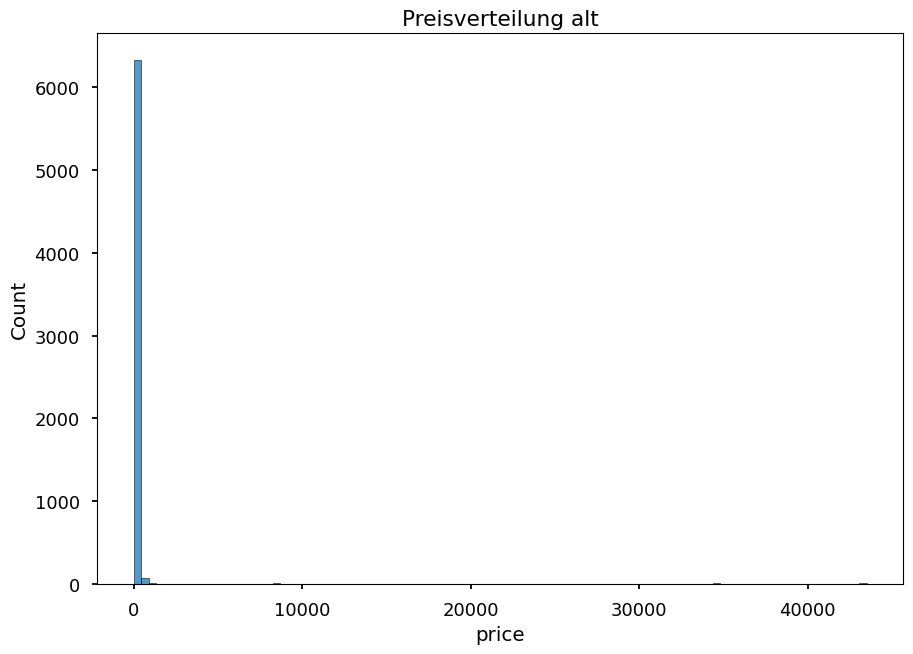

In [35]:
sns.histplot(df.price, bins=100)
plt.title("Preisverteilung alt");
plt.savefig("img/preisverteilung_alt.svg")

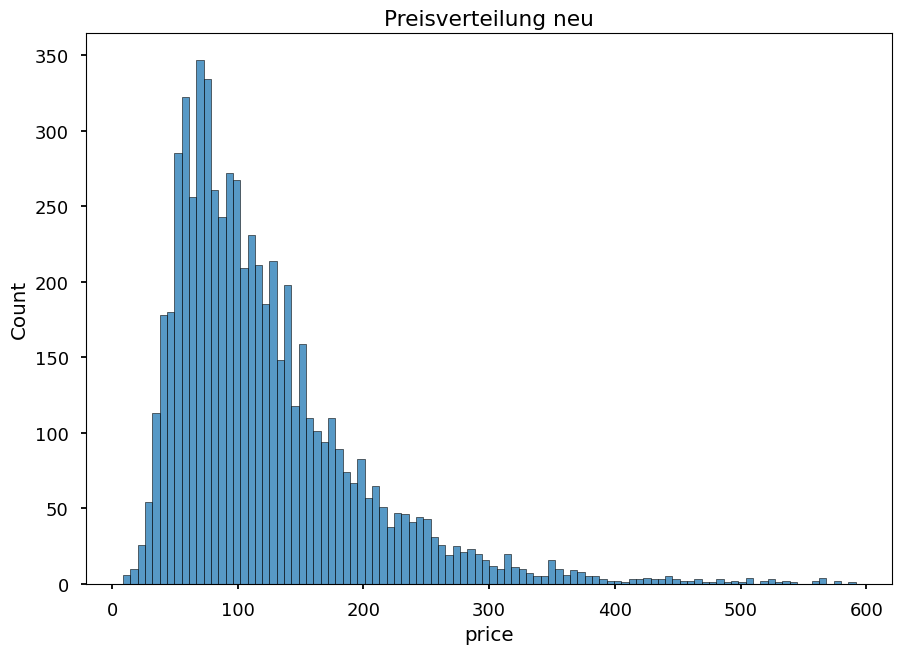

In [36]:
ausreisser = df.price.quantile(0.99)
df = df[df.price<ausreisser]
sns.histplot(df.price, bins=100)
plt.title("Preisverteilung neu");
plt.savefig("img/preisverteilung_neu.svg")

## 1.4 Fehlende Werte

Wohnungen ohne Rating erhalten ein künstliches, relative schlechtes Rating (20% Quantil)

In [39]:
rating_impute = df.review_scores_rating.quantile(0.2)
df['review_scores_rating'] = df.review_scores_rating.fillna(rating_impute)

FeWos mit fehlenden Werten können vom Maschine Learning Modell nicht berücksichtigt werden, und werden daher gelöscht.    

In [40]:
df.dropna(inplace=True)

## 1.5 Spezielle Features

Die Mermale der Spalte "Amenities" (Wifi, Kitchen, Pool, ...) muss transformiert werden, damit sie vom ML Modell genutzt werden kann. Jede Amenity, die ins Modell einfließen soll, muss als eigene Spalte des Typs "Boolean" repräsentiert werden.

In [41]:
import ast
df['amenities'] = df.amenities.apply(ast.literal_eval)
amenities =df.amenities.explode().pipe(pd.get_dummies).groupby(level=0).any()
amenity_cols = ['Wifi','Kitchen','Bed linens', 'Dedicated workspace', 'BBQ grill', 'Air conditioning', "Bikes", "Waterfront","Sauna"]
amenities_selection = amenities[amenity_cols]
df = pd.concat([df, amenities_selection], axis=1)
df.drop(columns=['amenities'], inplace=True)
df.head(3)

,id,listing_url,price,neighbourhood_group_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,number_of_reviews,...,minimum_nights,Wifi,Kitchen,Bed linens,Dedicated workspace,BBQ grill,Air conditioning,Bikes,Waterfront,Sauna
1,9991,https://www.airbnb.com/rooms/9991,117.45,Pankow,Entire rental unit,Entire home/apt,7,2.5,4.0,7,...,6,True,True,True,False,False,False,False,False,False
4,20858,https://www.airbnb.com/rooms/20858,175.74,Pankow,Entire loft,Entire home/apt,4,1.0,2.0,140,...,3,True,True,False,False,False,False,False,False,False
6,22677,https://www.airbnb.com/rooms/22677,132.24,Mitte,Entire rental unit,Entire home/apt,5,1.0,2.0,600,...,4,True,True,False,True,False,False,False,False,False


# 2. Überwachtes Maschinelles Lernen

In [42]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error

## 2.1 Train-Test Split

Zunächst wird die Target Variable "Preis" (y) von den Features (X) getrennt.

In [43]:
y = df["price"]
X_all = df.drop(columns=["price"])

80% der Ferienwohnungen (bezogen auf X und y) werden in einen Trainingsdatensatz überführt. Die restlichen 20% der Ferienwohnungen werden in einem Testdatensatz gespeichert. 
Motivation: wir wollen die Güte unsere Preisvorhersage objektiv testen. Daher ist wichtig, dass die Evaluierung unserer Ergebnisse, auf einem externen Datensatz durchgeführt wird, der nicht beim Training des Modells verwendet wurde. 

In [44]:

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y,
    test_size=0.2,
    random_state=1,
    shuffle=True
)

## 2.2 Training und Testen

### Naive Referenz

Wie hoch währe der MAE wenn man immer den durchschnittlichen Preis (122.8€) als Vorhersage verwenden würde?

In [45]:
durschnittspreis = y_train.mean()
print(f"Durschnittlicher FeWo-Preis: {durschnittspreis}")
baseline_mae = mean_absolute_error(y_test, np.full_like(y_test, durschnittspreis))
print(f"Naive Referenz: {baseline_mae}")

Durschnittlicher FeWo-Preis: 122.83023612750885
Naive Referenz: 55.187279322494255


### Lineare Regression

Es sollen verschiedene Modelle unterschiedlicher Komplexität (weniger Features, ..., viele Features) trainiert werden. Daher werden zunächst verschiedene Feature Sets definiert.

In [46]:
feature_sets = [
    # Kapazität
    ["accommodates"], 

    # ... + Unterkunftstyp
    ["accommodates", "bedrooms", "bathrooms","number_of_reviews", "review_scores_rating"], 

    # ... + Ratings
    ["accommodates", "bedrooms", "bathrooms","number_of_reviews", "review_scores_rating","property_type", "room_type", ], 

    # ... + Lage
    ["accommodates", "bedrooms", "bathrooms","property_type", "room_type", "number_of_reviews", "review_scores_rating", 
     "neighbourhood_group_cleansed"], 

    # ... + ausgewählte Annehmlichkeiten
    ["accommodates", "bedrooms", "bathrooms","property_type", "room_type", "number_of_reviews", "review_scores_rating", 
     "neighbourhood_group_cleansed"] + amenity_cols
]

Der nächste Code Block enthält diverse Schritte. Konkret wird für jedes einzelne Feature Set folgende Schritte ausgeführt:

- a) Zunächst werden die Features geeignet transformiert, um sie für die Modelle geeignet nutzbar zu machen
    - Numerische Features werden standardisiert (Mittelwert wird 0, Standardabweichung wird 1)
    - Kategorische Features werden in binäre Features umgewandelt. Z.B. wird die "neighbourhood" Spalte in separate Spalten für jeden Stadtteil (Pankow, Mitte, Neukölln) umgewandelt.
- b) Eine lineare Regression der Form $y = a + bX + e$ wird auf den Traininsdaten durchgeführt. Daraus resultieren Schätzwerte $\hat{b}$ für den Einfluss der verschiedenen Features X (Anzahl Gäste, Bewertungen, etc.) auf y (den Preis). 
- c) Für alle Ferienwohnungen des Testdatensatzes werden Preise vorhergesagt ($\hat{y} = \hat{b}X$)
- d) Nun kann die Güte mithilfe der Metrik Mean Absolute Error (MAE) evaluiert werden. Für jede FeWo ist der Fehler dabei gegeben als Abweichung des tatsächlichen Preises vom vorhergesagten Preis ($\hat{y}-y$).

In [47]:
results = []

for features in feature_sets:

    X_train = X_train_all[features]
    X_test = X_test_all[features]

    num_cols = X_train.select_dtypes(include='number').columns
    cat_cols = X_train.select_dtypes(exclude='number').columns

    preprocess = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
        ])
    
    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("lr", LinearRegression())
    ])

    # Transformation der Features und Fit der linearen Regression auf den Trainingsdaten
    model.fit(X_train, y_train)

    # Transformation der Features und Preis-Vorhersage auf den Testdaten 
    y_pred = model.predict(X_test)

    # Fehlermetrik
    mae = mean_absolute_error(y_test, y_pred)
    results.append((features, mae))
    
results_df = pd.DataFrame(results, columns=["features", "mae"])
results_df.style


,features,mae
0,['accommodates'],43.678137
1,"['accommodates', 'bedrooms', 'bathrooms', 'number_of_reviews', 'review_scores_rating']",43.118434
2,"['accommodates', 'bedrooms', 'bathrooms', 'number_of_reviews', 'review_scores_rating', 'property_type', 'room_type']",36.791542
3,"['accommodates', 'bedrooms', 'bathrooms', 'property_type', 'room_type', 'number_of_reviews', 'review_scores_rating', 'neighbourhood_group_cleansed']",35.615564
4,"['accommodates', 'bedrooms', 'bathrooms', 'property_type', 'room_type', 'number_of_reviews', 'review_scores_rating', 'neighbourhood_group_cleansed', 'Wifi', 'Kitchen', 'Bed linens', 'Dedicated workspace', 'BBQ grill', 'Air conditioning', 'Bikes', 'Waterfront', 'Sauna']",35.507080


### Random Forest

In [48]:
from sklearn.ensemble import RandomForestRegressor

X_train = X_train_all[feature_sets[-1]]
X_test = X_test_all[feature_sets[-1]]

rf = RandomForestRegressor(random_state=42, n_estimators=300, n_jobs=-1)
pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf)
])

pipeline.fit(X_train, y_train)
rf_pred = pipeline.predict(X_test)
rm_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest MAE:", rm_mae)

Random Forest MAE: 33.543559520463155


Prozentualer Fehler des Random Forest Modells bezogen auf den Durschnittspreis

In [49]:
print(f"{rm_mae / durschnittspreis}")

0.27308878154106875


Wir können auch im Datensatz vergleichen, wie tatsächlicher Preis und vorhergesagter Preis voneinander abweichen

In [50]:
test_with_predictions = X_test.copy()
test_with_predictions.insert(0, "listing_url", df.loc[test_with_predictions.index, "listing_url"])
test_with_predictions.insert(1, "price", y_test)
test_with_predictions.insert(2, "rf_pred", rf_pred)
test_with_predictions.head()

,listing_url,price,rf_pred,accommodates,bedrooms,bathrooms,property_type,room_type,number_of_reviews,review_scores_rating,neighbourhood_group_cleansed,Wifi,Kitchen,Bed linens,Dedicated workspace,BBQ grill,Air conditioning,Bikes,Waterfront,Sauna
4677,https://www.airbnb.com/rooms/30515744,120.06,136.218800,3,0.0,1.0,Entire serviced apartment,Entire home/apt,90,4.82,Mitte,True,True,True,True,False,False,False,False,False
745,https://www.airbnb.com/rooms/3969577,565.50,160.308520,2,4.0,1.5,Entire loft,Entire home/apt,6,5.00,Charlottenburg-Wilm.,True,True,False,False,False,False,False,False,False
13773,https://www.airbnb.com/rooms/1456632627930300605,74.82,44.644533,1,1.0,1.0,Private room in rental unit,Private room,0,4.61,Spandau,True,True,False,False,False,False,False,False,False
5144,https://www.airbnb.com/rooms/34708500,174.00,91.959000,2,0.0,1.0,Entire rental unit,Entire home/apt,68,4.87,Friedrichshain-Kreuzberg,True,True,True,False,False,False,False,False,False
13575,https://www.airbnb.com/rooms/1436998025030443852,117.45,139.489033,4,2.0,1.0,Entire rental unit,Entire home/apt,11,5.00,Steglitz - Zehlendorf,True,True,True,True,False,False,False,False,False
